In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv("origin/projects_data.csv")

In [3]:
df.head(20)

,Project_ID,Time_Step,Feature_1,Feature_2,Feature_3,Success
0,1,1,0.374540,0.950714,0.731994,NaN
1,1,2,0.598658,0.156019,0.155995,NaN
2,1,3,0.058084,0.866176,0.601115,NaN
3,1,4,0.708073,0.020584,0.969910,NaN
4,1,5,0.832443,0.212339,0.181825,NaN
5,1,6,0.183405,0.304242,0.524756,NaN
6,1,7,0.431945,0.291229,0.611853,NaN
7,1,8,0.139494,0.292145,0.366362,NaN
8,1,9,0.456070,0.785176,0.199674,NaN
9,1,10,0.514234,0.592415,0.046450,0.0


array([[<Axes: title={'center': 'Success'}>]], dtype=object)

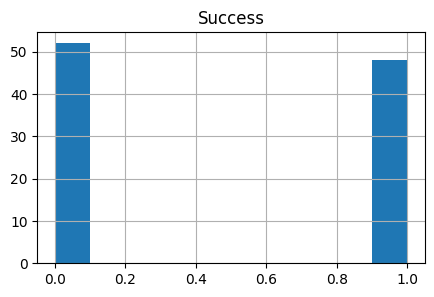

In [4]:
df[['Success']].hist(figsize=(5,3))

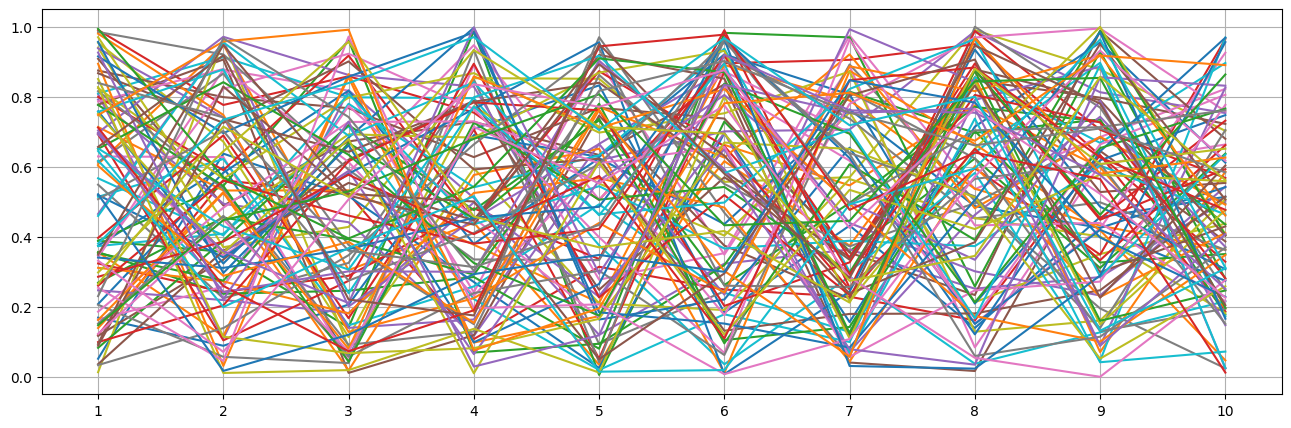

In [5]:
num_cycles = len(df) // 10

plt.figure(figsize=(16, 5))

for i in range(num_cycles):
    start_index = i * 10
    end_index = start_index + 10
    plt.plot(df['Feature_1'][start_index:end_index].values, label=f'Cycle {i + 1}')

plt.xticks(ticks=np.arange(10), labels=np.arange(1,11))
plt.grid();

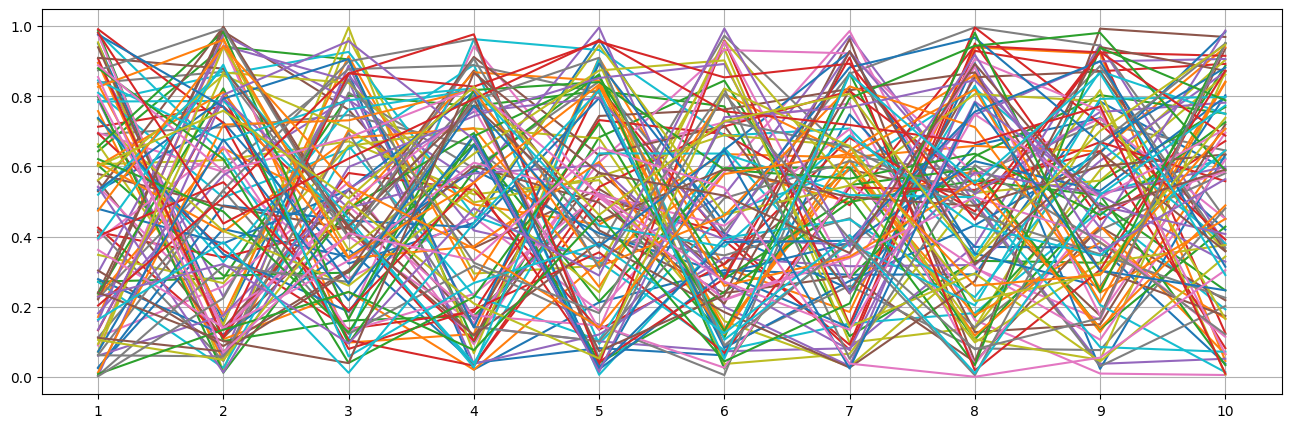

In [6]:
plt.figure(figsize=(16, 5))

for i in range(num_cycles):
    start_index = i * 10
    end_index = start_index + 10
    plt.plot(df['Feature_2'][start_index:end_index].values, label=f'Cycle {i + 1}')


plt.xticks(ticks=np.arange(10), labels=np.arange(1,11))
plt.grid();

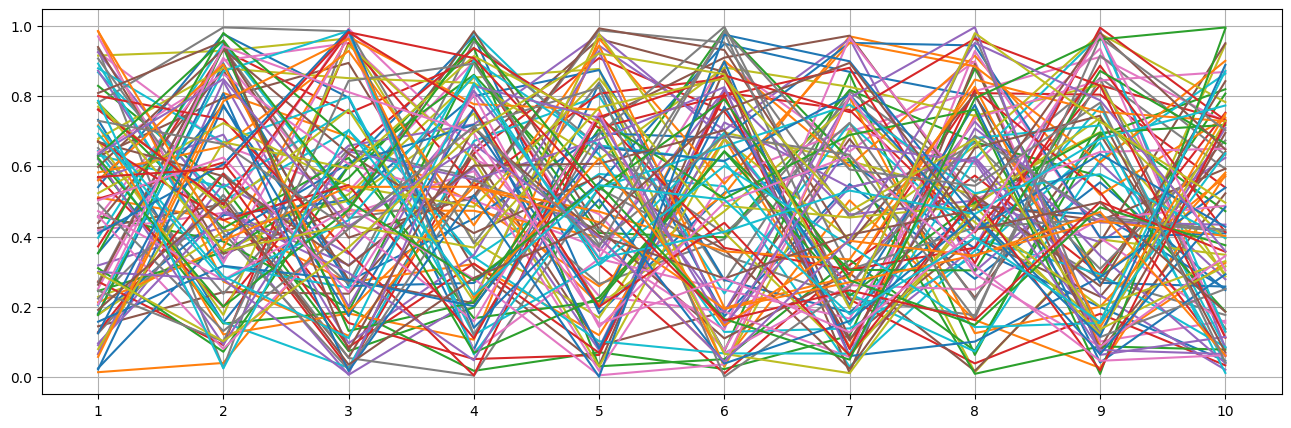

In [7]:
num_cycles = len(df) // 10
plt.figure(figsize=(16, 5))

for i in range(num_cycles):
    start_index = i * 10
    end_index = start_index + 10
    plt.plot(df['Feature_3'][start_index:end_index].values, label=f'Cycle {i + 1}')

plt.xticks(ticks=np.arange(10), labels=np.arange(1,11))
plt.grid();

In [8]:
df.set_index(['Project_ID', 'Time_Step'], inplace=True)

In [9]:
#scaler = StandartScaler()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Feature_1', 'Feature_2', 'Feature_3', 'Success']])

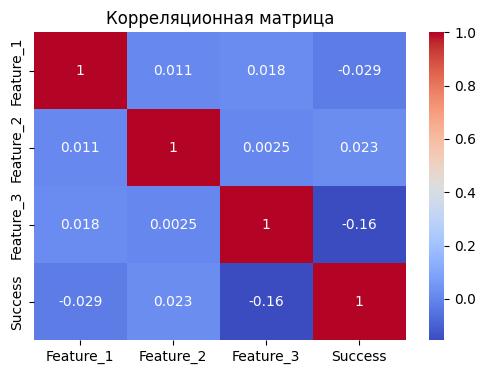

In [19]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Feature_1', 'Feature_2', 'Feature_3', 'Success']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица');

Feature_1  Feature_2  Feature_3  Success
Project_ID Time_Step                                          
1          1           0.374540   0.950714   0.731994      NaN
           2           0.598658   0.156019   0.155995      NaN
           3           0.058084   0.866176   0.601115      NaN
           4           0.708073   0.020584   0.969910      NaN
           5           0.832443   0.212339   0.181825      NaN
...                         ...        ...        ...      ...
100        6           0.967035   0.051669   0.504796      NaN
           7           0.718454   0.862640   0.179256      NaN
           8           0.800003   0.552707   0.396554      NaN
           9           0.131715   0.865296   0.157273      NaN
           10          0.309788   0.290046   0.871414      0.0

[1000 rows x 4 columns]

In [12]:
df.values

array([[0.37454012, 0.95071431, 0.73199394,        nan],
       [0.59865848, 0.15601864, 0.15599452,        nan],
       [0.05808361, 0.86617615, 0.60111501,        nan],
       ...,
       [0.80000348, 0.55270708, 0.39655368,        nan],
       [0.13171503, 0.86529576, 0.15727321,        nan],
       [0.30978786, 0.29004553, 0.87141403, 0.        ]])

In [13]:
def create_sequences(data, time_steps=1):
    X, y = [], []
    for i in range(0,len(data) - time_steps, time_steps):
        X.append(data[i:(i + time_steps), :-1])  # признаки
        y.append(data[i + time_steps-1, -1])  # таргет
        
    return np.array(X), np.array(y)

time_steps = 10
X, y = create_sequences(scaled_data, time_steps)

len_train = 70
X_train, X_test, y_train, y_test = X[:len_train], X[len_train:], y[:len_train], y[len_train:]
# изменение формы данных для LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], 10, X_train.shape[2]))

In [22]:
X_train

array([[[0.37456163, 0.9522874 , 0.73405866],
        [0.59877349, 0.15626705, 0.15536439],
        [0.05797309, 0.86760832, 0.60256741],
        ...,
        [0.13941731, 0.29261997, 0.36671593],
        [0.4561255 , 0.78647311, 0.19924801],
        [0.51431422, 0.59339041, 0.04530777]],

       [[0.60766357, 0.17079672, 0.06399598],
        [0.94914666, 0.96722999, 0.81081952],
        [0.3046061 , 0.09782327, 0.68607429],
        ...,
        [0.77532145, 0.94105334, 0.89765389],
        [0.59801467, 0.92339925, 0.08754656],
        [0.19592988, 0.04529102, 0.32549245]],

       [[0.38870469, 0.27178969, 0.83125485],
        [0.35676741, 0.28139114, 0.54387516],
        [0.14084827, 0.80352251, 0.07353947],
        ...,
        [0.62342341, 0.33143794, 0.06249575],
        [0.31097731, 0.32571372, 0.73165972],
        [0.63768871, 0.88867998, 0.47306425]],

       ...,

       [[0.03349287, 0.06274599, 0.90931832],
        [0.13916871, 0.53329652, 0.41165898],
        [0.34735349, 0

In [50]:
model = keras.models.Sequential(
    [
        keras.layers.LSTM(10, activation='tanh', return_sequences=False, 
            input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')  
    ]
)

model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001),
              loss='binary_crossentropy', 
              metrics=['accuracy'])


early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=False)

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2, 
                    #callbacks=[early_stopping]
                   )

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.5238 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.7036
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4807 - loss: 0.7113 - val_accuracy: 0.5000 - val_loss: 0.7036
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5119 - loss: 0.7073 - val_accuracy: 0.5000 - val_loss: 0.7036
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5670 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.7036
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5134 - loss: 0.7099 - val_accuracy: 0.5000 - val_loss: 0.7036
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5551 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.7035
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5015 - loss: 0.7158 - val_accuracy: 0.5000 - val_loss: 0.7035
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4568 - loss: 0.7104 - val_accuracy: 0.5000 - val_loss: 0.7035

In [51]:
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Loss: {loss}, Accuracy: {accuracy}')

Loss: 0.7062108516693115, Accuracy: 0.48275861144065857


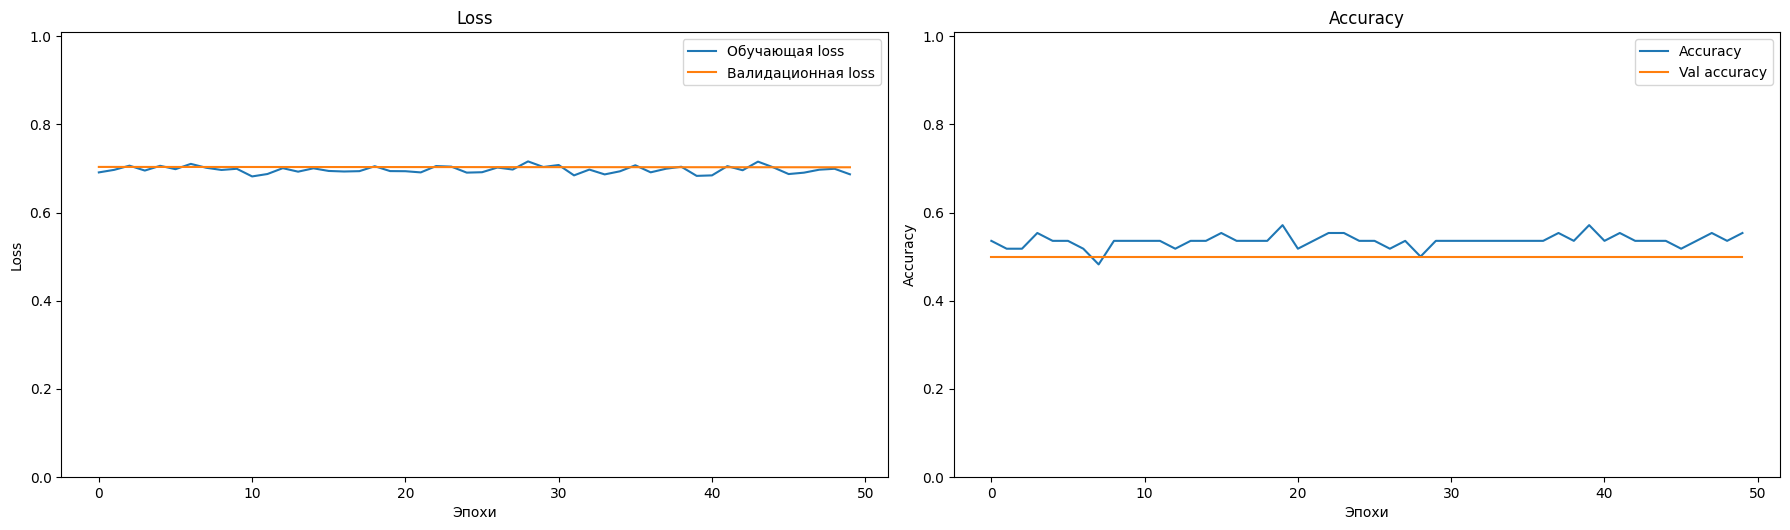

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))

plt.subplot(2, 2, 1) 
plt.plot(history.history['loss'], label='Обучающая loss')
plt.plot(history.history['val_loss'], label='Валидационная loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()
plt.ylim(0,1.01)

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.ylim(0,1.01)

plt.tight_layout()  # автоматически подгоняет подграфики
plt.show()

In [18]:
num = 13
sample_input = X_test[num]
sample_input = sample_input.reshape((1, sample_input.shape[0], sample_input.shape[1]))

prediction = model.predict(sample_input)
print(prediction, y_test[num])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
[[0.1314906]] 1.0
